# 최대수요전력 예측 Baseline Preprocessing
모델 예측에 사용하기 위한 데이터 전처리 과정을 기술한다.

## 1. 필요 패키지 호출

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from data_load import dataset

## 2. 데이터 셋 확인

In [3]:
dataset.head(10)

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5
5,20210101,5,89,83,99,98,92,0,-5.5,2.1,66,0.0,109.8,5,1,1,0.0,1.5
6,20210101,6,102,111,110,103,107,0,-5.6,1.5,67,0.0,109.8,5,1,1,0.0,1.5
7,20210101,7,92,75,48,29,61,0,-6.8,0.6,73,0.0,109.8,5,1,1,0.0,1.5
8,20210101,8,27,25,22,22,24,0,-5.6,0.0,72,0.0,109.8,5,1,1,0.0,1.5
9,20210101,9,22,22,22,22,22,0,-3.3,1.2,62,0.0,109.8,5,1,1,0.0,1.0


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


## 3. 결측치 제거

In [5]:
dataset.isnull().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

### interploate : 선형 보간
전 값과 이후 값의 평균으로 결측치를 채운다.

해당 데이터는 시간 단위로 주어진 데이터인 점을 감안하였을 때, 선형관계를 포함할 확률이 높다고 판단하여 선형 보간을 실시한다.

In [6]:
dataset_interpolate = dataset.interpolate()
dataset_interpolate.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

## 4. 피쳐 추출

### 상관관계 확인

상관관계는 두 변수의 변화가 서로 어떤 방향과 정도로 함께 움직이는지를 나타낸다. 상관계수는 -1과 1 사이의 값을 가지며, 1에 가까울수록 강한 양의 상관관계, -1에 가까울수록 강한 음의 상관관계, 0에 가까울수록 선형적인 관계가 약함을 의미한다.

- Pearson 상관계수: 선형 관계의 강도 측정
- Spearman 상관계수: 순위를 이용한 단조 관계의 강도 측정
- 상관관계가 높더라도 한 변수가 다른 변수의 원인이라는 뜻은 아니므로 인과관계와 구분해야 한다.

아래에서는 Pearson 상관계수와 Spearman 상관계수를 각각 계산하고 heatmap으로 비교한다. 두 결과가 비슷하면 선형 관계가 뚜렷할 가능성이 있고, 차이가 크면 비선형적인 단조 관계나 이상치의 영향을 확인할 필요가 있다.

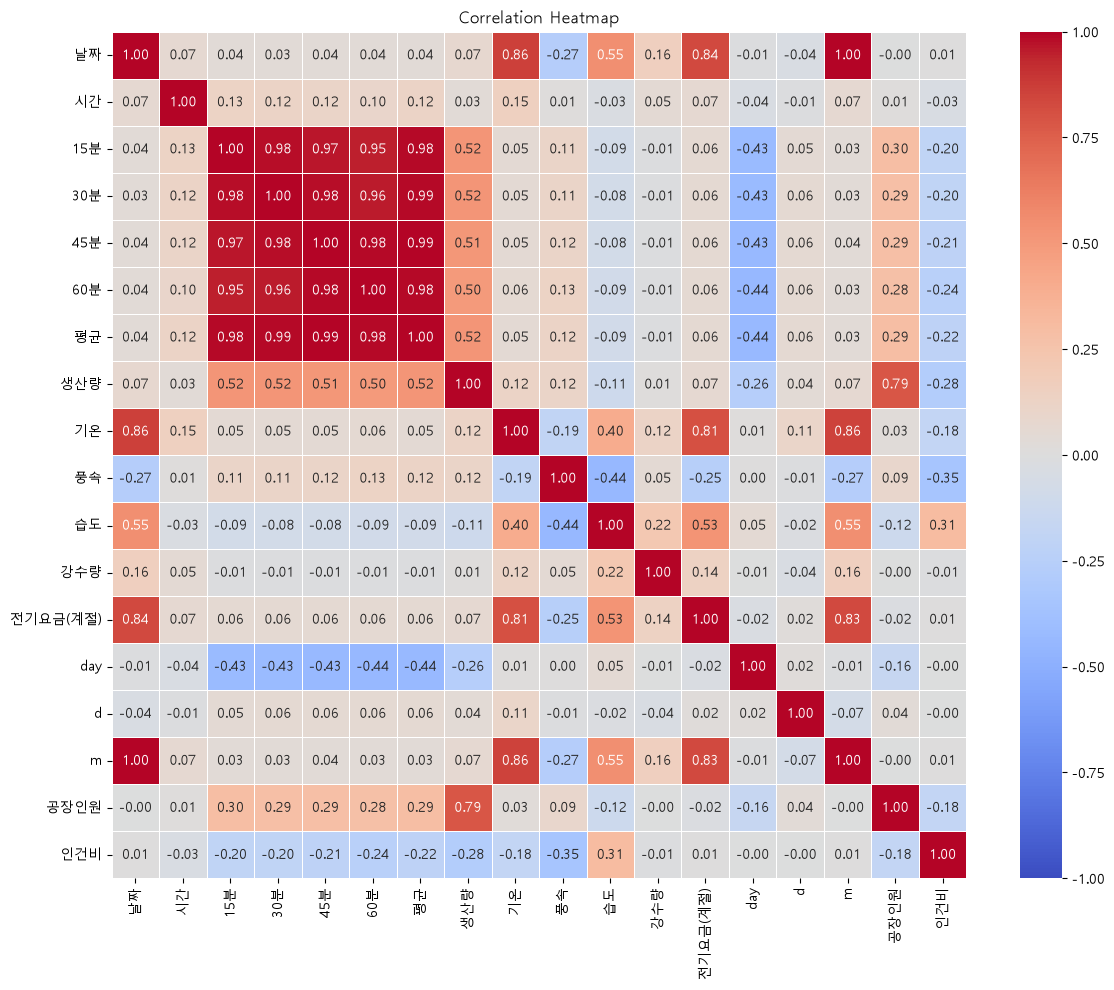

In [7]:
dataset_corr = dataset_interpolate.corr()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 10))

sns.heatmap(
    dataset_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,      
    fmt=".2f",      
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

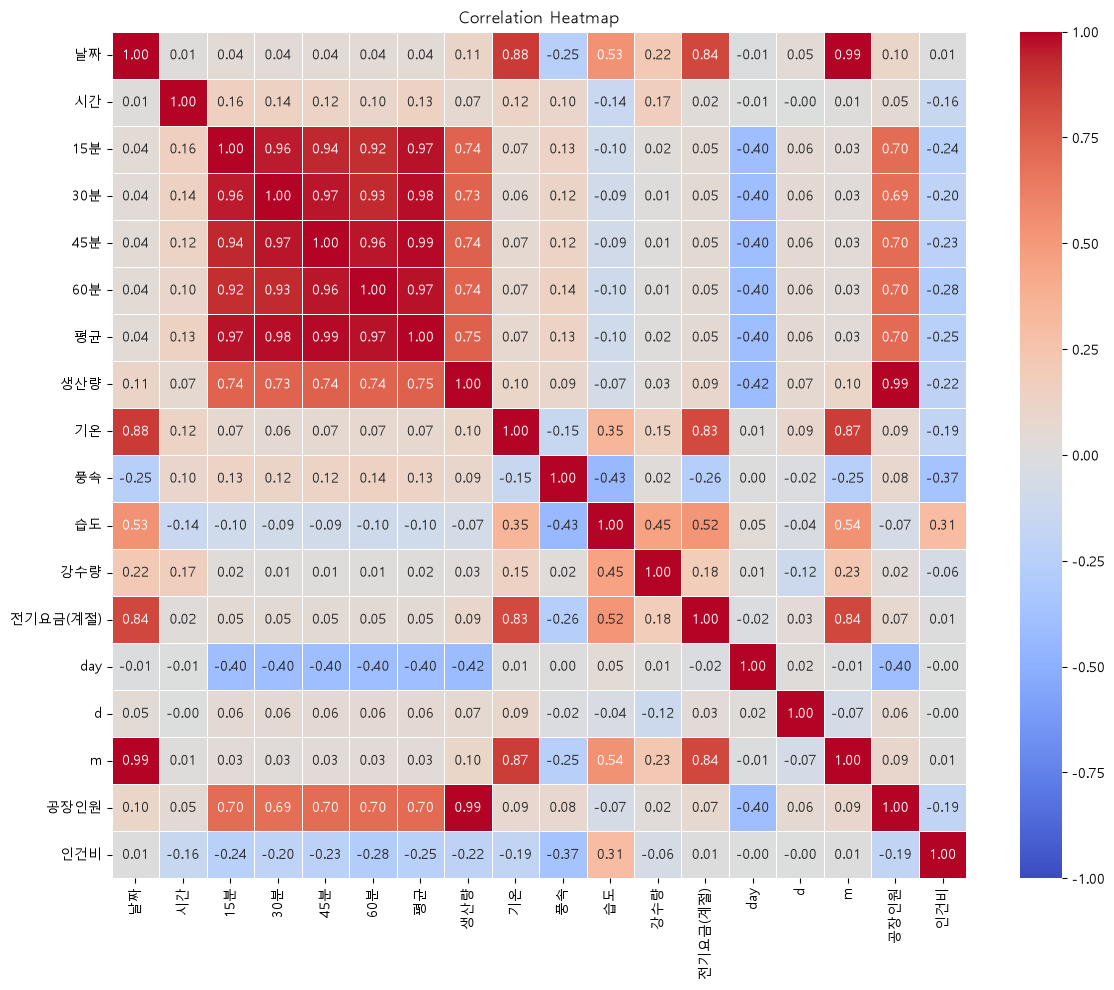

In [8]:
dataset_corr = dataset_interpolate.corr(method='spearman')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 10))

sns.heatmap(
    dataset_corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,      
    fmt=".2f",      
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

상관관계 분석 결과 비교적 상관관계가 적은 컬럼을 제거한다. 

또한 생산량은 생산량 자체로 이용하지 않고 공장 가동여부를 판단하기 위한 피쳐로 활용한다.

In [9]:
drop_cols = ['평균', '생산량', '기온', '풍속', '습도',
             '강수량', '전기요금(계절)', 'day', 'd', 'm', '인건비']

dataset_interpolate['is_operated'] = (dataset_interpolate['생산량'] > 0.0).astype(float)
dataset_drop = dataset_interpolate.drop(columns=drop_cols)

dataset_drop.info()

<class 'pandas.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   날짜           6168 non-null   int64  
 1   시간           6168 non-null   int64  
 2   15분          6168 non-null   int64  
 3   30분          6168 non-null   int64  
 4   45분          6168 non-null   int64  
 5   60분          6168 non-null   int64  
 6   공장인원         6168 non-null   float64
 7   is_operated  6168 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 385.6 KB


날짜와 시간을 합쳐서 DataFrame의 Index로 활용한다

In [10]:
print(dataset_drop['날짜'].iloc[0], dataset_drop['날짜'].iloc[-1])

20210101 20210914


In [11]:
data_idx = pd.date_range(start='2021-01-01 00:00', end='2021-09-14 23:00', freq='h')

dataset_drop.index = data_idx
dataset_drop.index.names = ['Dates']

dataset_reindex = dataset_drop.drop(columns=['날짜', '시간'])
dataset_reindex.head()


,15분,30분,45분,60분,공장인원,is_operated
Dates,,,,,,
2021-01-01 00:00:00,62,61,61,61,0.0,0.0
2021-01-01 01:00:00,96,93,116,113,0.0,0.0
2021-01-01 02:00:00,106,96,106,107,0.0,0.0
2021-01-01 03:00:00,92,110,110,109,0.0,0.0
2021-01-01 04:00:00,108,105,106,108,0.0,0.0


In [12]:
dataset_float = dataset_reindex.astype(float)
dataset_float.head()

,15분,30분,45분,60분,공장인원,is_operated
Dates,,,,,,
2021-01-01 00:00:00,62.0,61.0,61.0,61.0,0.0,0.0
2021-01-01 01:00:00,96.0,93.0,116.0,113.0,0.0,0.0
2021-01-01 02:00:00,106.0,96.0,106.0,107.0,0.0,0.0
2021-01-01 03:00:00,92.0,110.0,110.0,109.0,0.0,0.0
2021-01-01 04:00:00,108.0,105.0,106.0,108.0,0.0,0.0


### 15분 단위 데이터로 변환

원본 데이터는 한 행이 한 시간에 해당하고, 각 행 안에 `15분`, `30분`, `45분`, `60분` 시점의 전력량이 별도 열로 저장되어 있다. 하지만 LSTM 모델은 시간 순서에 따라 나열된 시계열 데이터를 입력으로 사용하므로, 각 15분 구간을 독립적인 행으로 변환한다.

변환 과정은 다음과 같다.

1. 원본의 시간별 행을 순회한다.
2. 각 행에서 `15분`, `30분`, `45분`, `60분` 열을 차례로 확인한다.
3. 원래 시각에 각각 15분, 30분, 45분, 60분을 더해 새로운 타임스탬프를 만든다.
4. 각 시점의 전력량과 해당 시간의 `공장인원`, `is_operated` 값을 새로운 행에 함께 저장한다.
5. 결과를 긴 형식의 데이터프레임으로 만들고, 새 날짜·시간을 인덱스로 설정한다.

따라서 시간당 한 행이 15분 단위의 네 행으로 바뀌며, 전체 행 수는 대략 네 배가 된다. 이 과정을 통해 데이터의 시간 간격을 1시간에서 15분으로 세분화할 수 있고, 이후 하루를 96개 시점(24시간 × 4개 구간)으로 구성하여 LSTM의 입력 시퀀스를 만들 수 있다.

`공장인원`과 `is_operated`는 각 1시간에 대해 동일한 값이 반복되어 15분 단위 행에 복사된다. 반면 `전력량`은 각 15분 구간에 해당하는 원본 열의 값을 사용한다. 최종적으로 데이터프레임은 `Date`를 인덱스로 하고, `전력량`, `공장 인원`, `is_operated`를 열로 갖는 시계열 형태가 된다.

In [13]:
data_15min = []

for date, row in dataset_float.iterrows():

    for col, minutes in [
        ('15분', 15),
        ('30분', 30),
        ('45분', 45),
        ('60분', 60)
    ]:
        
        new_date = date + pd.Timedelta(minutes=minutes)
        
        data_15min.append([
            new_date,
            row[col],
            row['공장인원'],
            row['is_operated']
        ])

data_15min = pd.DataFrame(
    data_15min,
    columns=['Date', '전력량', '공장 인원', 'is_operated']
)

data_15min = data_15min.set_index('Date')

data_15min.head()

,전력량,공장 인원,is_operated
Date,,,
2021-01-01 00:15:00,62.0,0.0,0.0
2021-01-01 00:30:00,61.0,0.0,0.0
2021-01-01 00:45:00,61.0,0.0,0.0
2021-01-01 01:00:00,61.0,0.0,0.0
2021-01-01 01:15:00,96.0,0.0,0.0


### 휴일·시간·요일 피처 생성

전력 수요는 단순히 과거 전력량만으로 결정되지 않고, 해당 날짜가 휴일인지, 하루 중 몇 시인지, 어떤 요일인지에 따라 달라질 수 있다. 따라서 날짜와 시간에서 반복적으로 나타나는 패턴을 모델이 학습할 수 있도록 다음과 같은 피처를 추가한다.

#### 1. 휴일 피처

`holidays`에 정의한 공휴일 날짜와 각 데이터의 날짜를 비교하여 `Vacation` 피처를 만든다. 해당 날짜가 휴일이면 `1`, 휴일이 아니면 `0`으로 표시한다. 휴일에는 공장 운영 여부와 생산 활동이 평일과 달라질 수 있으므로, 이 피처는 전력 수요의 수준 변화를 설명하는 데 활용된다..

#### 2. 시간 피처의 주기적 변환

하루의 시간은 23시 다음에 0시가 다시 나타나는 순환형 변수이다. 시간을 단순한 숫자로 사용하면 23시와 0시가 멀리 떨어진 값으로 인식되지만, 실제로는 서로 인접한 시점이다. 이를 보완하기 위해 하루 중 경과한 분(`minute_of_day`)을 삼각함수로 변환한다.

$$
time\_sin = \sin\left(2\pi \frac{minute\_of\_day}{1440}\right),
$$

$$
time\_cos = \cos\left(2\pi \frac{minute\_of\_day}{1440}\right)
$$

하루는 24시간, 즉 1,440분이므로 `minute_of_day`를 1,440으로 나누어 하루 주기의 위치를 계산한다. `sin`과 `cos`를 함께 사용하면 0시와 24시가 자연스럽게 연결되며, 모델이 시간대별 전력 수요의 반복 패턴을 학습할 수 있다.

#### 3. 요일 원-핫 인코딩

`day_of_week`는 월요일을 0, 일요일을 6으로 나타낸다. 요일 숫자를 그대로 사용하면 일요일(6)이 월요일(0)보다 훨씬 큰 값이라는 잘못된 순서 관계가 생길 수 있다. 이를 방지하기 위해 각 요일을 별도의 0 또는 1 값으로 표현하는 원-핫 인코딩을 적용한다.

예를 들어 월요일은 `day_0=1`이고 나머지 요일 피처는 0이 된다. 이 방식은 각 요일을 서로 독립적인 범주로 취급하므로, 평일과 주말처럼 요일별로 다른 전력 수요 패턴을 모델이 구분할 수 있게 한다.


In [14]:
holidays = ['2021-01-01', '2021-02-11', '2021-02-12', '2021-03-01', '2021-05-05',
            '2021-05-19', '2021-08-16']

data_15min['Vacation'] = (
    data_15min.index.normalize().isin(holidays)
).astype(float)

data_15min['minute_of_day'] = (
    data_15min.index.hour * 60
    + data_15min.index.minute
)

data_15min['time_sin'] = np.sin(
    2 * np.pi * data_15min['minute_of_day'] / (24 * 60)
)

data_15min['time_cos'] = np.cos(
    2 * np.pi * data_15min['minute_of_day'] / (24 * 60)
)

data_15min['day_of_week'] = data_15min.index.dayofweek.astype(int)

day_of_week_onehot = pd.get_dummies(
    data_15min['day_of_week'],
    prefix='day',
    dtype=float,
)

data_timeinfo = pd.concat(
                    [data_15min, day_of_week_onehot], 
                    axis=1).drop(columns=['day_of_week', 'minute_of_day'])
data_timeinfo.head()

,전력량,공장 인원,is_operated,Vacation,time_sin,time_cos,day_0,day_1,day_2,day_3,day_4,day_5,day_6
Date,,,,,,,,,,,,,
2021-01-01 00:15:00,62.0,0.0,0.0,0.0,0.065403,0.997859,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2021-01-01 00:30:00,61.0,0.0,0.0,0.0,0.130526,0.991445,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2021-01-01 00:45:00,61.0,0.0,0.0,0.0,0.195090,0.980785,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2021-01-01 01:00:00,61.0,0.0,0.0,0.0,0.258819,0.965926,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2021-01-01 01:15:00,96.0,0.0,0.0,0.0,0.321439,0.946930,0.0,0.0,0.0,0.0,1.0,0.0,0.0


### 이전 데이터를 피쳐로 활용

전력 데이터가 반복적인 특성을 가진다는 점을 이용하여, 1일전과 1주일 전의 전력량을 하나의 컬럼으로 구성한다.

또한 1시간 전과 1일 전의 운영 여부를 피쳐로 추가하여, 휴일이나 주말에는 나타나지 않는 공장 중단이나, 여름 휴가 등의 변수에 대비한다.

In [15]:
data_timeinfo['전력량_1일전'] = data_timeinfo['전력량'].shift(96)
data_timeinfo['전력량_1주일전'] = data_timeinfo['전력량'].shift(672)

data_timeinfo['is_operated_1시간전'] = data_timeinfo['is_operated'].shift(4)
data_timeinfo['is_operated_1일전'] = data_timeinfo['is_operated'].shift(96)

data_final = data_timeinfo.dropna()
data_final.head()

,전력량,공장 인원,is_operated,Vacation,time_sin,time_cos,day_0,day_1,day_2,day_3,day_4,day_5,day_6,전력량_1일전,전력량_1주일전,is_operated_1시간전,is_operated_1일전
Date,,,,,,,,,,,,,,,,,
2021-01-08 00:15:00,64.0,0.0,0.0,0.0,0.065403,0.997859,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,62.0,1.0,0.0
2021-01-08 00:30:00,63.0,0.0,0.0,0.0,0.130526,0.991445,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0,1.0,0.0
2021-01-08 00:45:00,63.0,0.0,0.0,0.0,0.195090,0.980785,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22.0,61.0,1.0,0.0
2021-01-08 01:00:00,62.0,0.0,0.0,0.0,0.258819,0.965926,0.0,0.0,0.0,0.0,1.0,0.0,0.0,25.0,61.0,1.0,0.0
2021-01-08 01:15:00,87.0,0.0,0.0,0.0,0.321439,0.946930,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.0,96.0,0.0,1.0


## 4. 데이터 저장

이후 모델에 사용하기 위하여 만든 데이터를 csv형태로 저장한다.

In [16]:
output_path = os.path.join('dataset', 'data_final.csv')
os.makedirs(os.path.dirname(output_path), exist_ok=True)

data_final.to_csv(
    output_path,
    index=True,
    encoding='utf-8-sig'
)

print(f'저장 완료: {output_path}')

저장 완료: dataset\data_final.csv
